# Libraries

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mode #for mode operation
from sklearn.preprocessing import MinMaxScaler #scaling numerical data
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_regression # mutual information library
from sklearn.model_selection import train_test_split # for train test split we have to import the method from scikit learn

# Read Dataset

In [51]:
filepath = "/content/drive/MyDrive/ICT_Data_Science/House_Pricing.csv"
hprice_df = pd.read_csv(filepath)

#Dataset Overview

In [52]:
hprice_df.shape # no of rows and columns

(21613, 21)

In [53]:
hprice_df.info() # Display dataset structure, column names, data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [54]:
hprice_df.describe() #To display the statistical details of dataframe

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [55]:
hprice_df.head()  #display dataframe

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


# Duplicates

In [56]:
hprice_df.duplicated().sum()

np.int64(0)

In [57]:
#There are no duplicates

#Missing values

In [58]:
# How many null values are in each column
hprice_df.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [59]:
#before dropping "No of Times Visited" column
hprice_df.columns

Index(['ID', 'Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [60]:
# No of times visited contain more than 50% above null or missing values so we drop that column
hprice_df = hprice_df.drop('No of Times Visited', axis=1)

In [61]:
#after dropping "No of Times Visited" column
hprice_df.columns

Index(['ID', 'Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'Condition of the House',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

## Histogram Plotting of missing values columns

In [62]:
num_cols = hprice_df.select_dtypes(include = ['int64','float64']).columns
cat_cols = hprice_df.select_dtypes(include = ['object']).columns
scale_cols = num_cols.drop(['ID', 'Sale Price', 'Zipcode'])


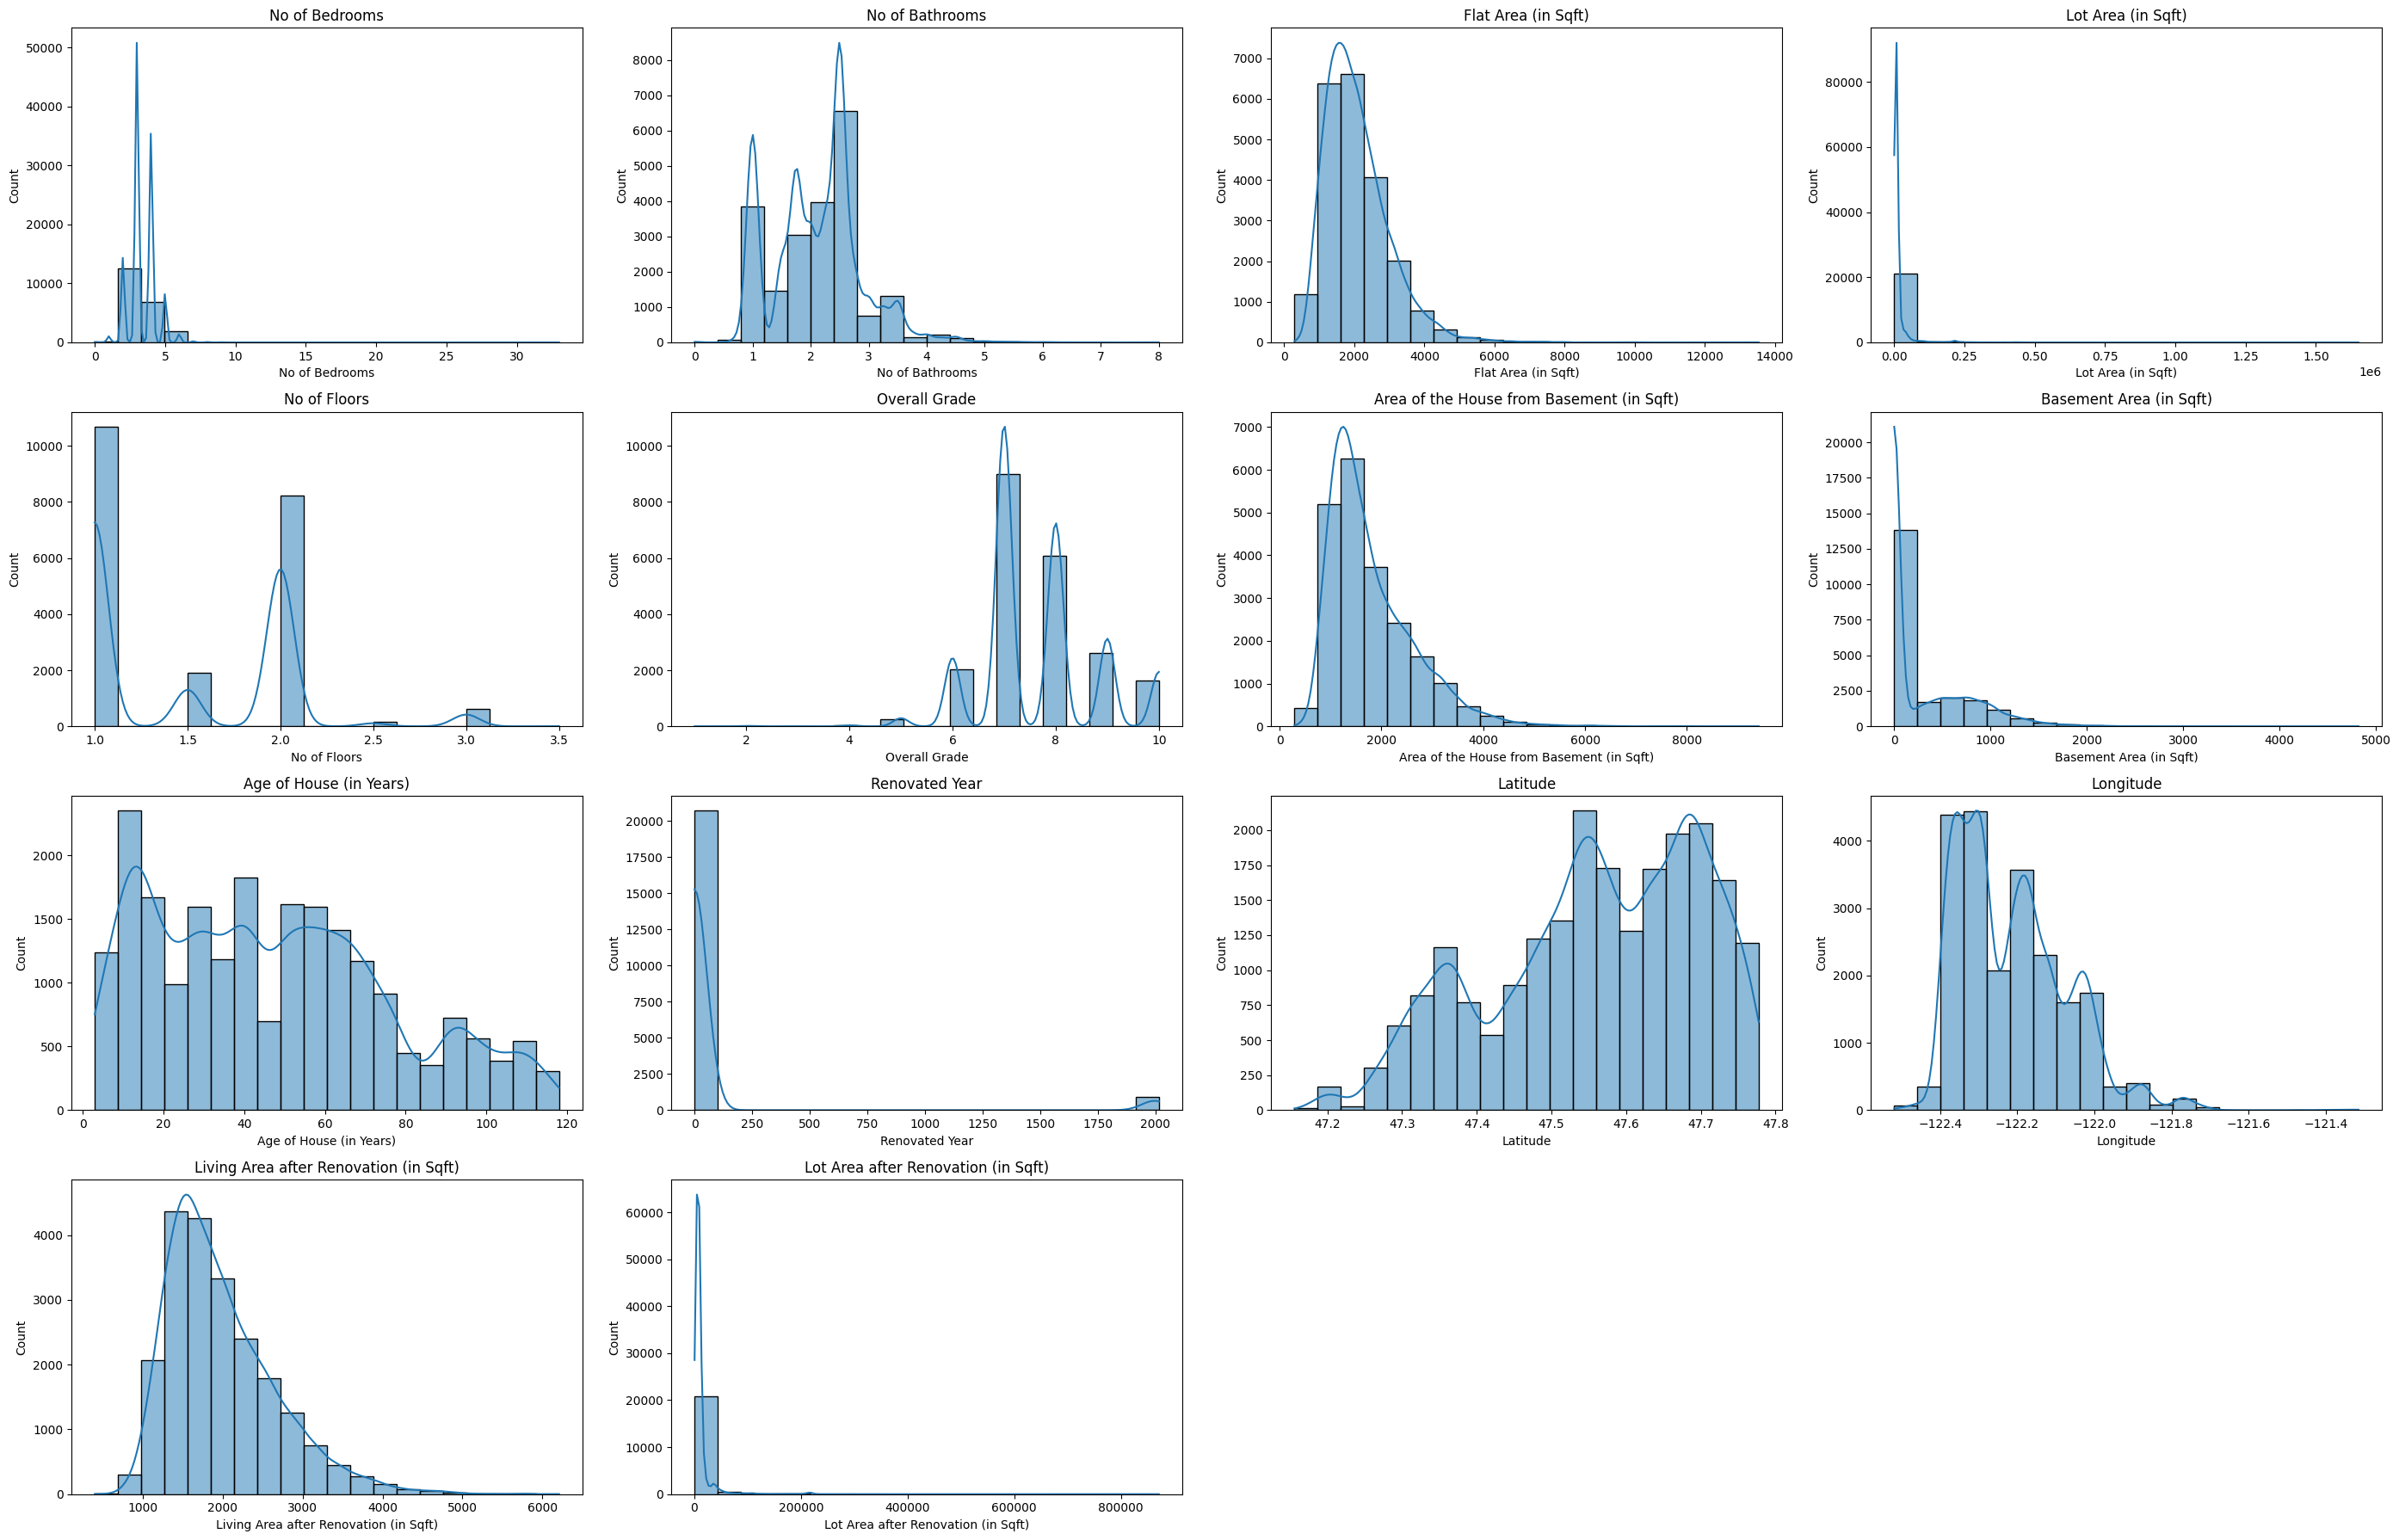

In [63]:
plt.figure(figsize=(28,18))

for i, scale_cols in enumerate(scale_cols,1):
    plt.subplot(4, 4, i)
    sns.histplot(hprice_df[scale_cols], bins=20, kde=True)
    plt.title(scale_cols)

plt.tight_layout()
plt.show()

## Removing and Replacing of column values

In [64]:
# Sale Price is the target column
#So instead of replacing values we are dropping the rows of missing values of sale price

#before dropping
print(hprice_df.isnull().sum())

hprice_df = hprice_df.dropna(subset=['Sale Price'], axis=0)

#After dropping
hprice_df.isnull().sum()

ID                                           0
Date House was Sold                          0
Sale Price                                   4
No of Bedrooms                               0
No of Bathrooms                              4
Flat Area (in Sqft)                          9
Lot Area (in Sqft)                           9
No of Floors                                 0
Waterfront View                              0
Condition of the House                       0
Overall Grade                                0
Area of the House from Basement (in Sqft)    3
Basement Area (in Sqft)                      0
Age of House (in Years)                      0
Renovated Year                               0
Zipcode                                      1
Latitude                                     1
Longitude                                    1
Living Area after Renovation (in Sqft)       1
Lot Area after Renovation (in Sqft)          0
dtype: int64


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


In [65]:
#Latitude
hprice_df = hprice_df.dropna(subset=['Latitude'], axis = 0)

#Longitude
hprice_df = hprice_df.dropna(subset=['Longitude'], axis = 0)

#Zipcode
hprice_df = hprice_df.dropna(subset=['Zipcode'],axis = 0)

#Living Area after Renovation (in Sqft)
hprice_df = hprice_df.dropna(subset=['Living Area after Renovation (in Sqft)'], axis = 0)






In [66]:
#No of Bathrooms replaced by mode
hprice_df['No of Bathrooms'] = hprice_df['No of Bathrooms'].fillna(mode(hprice_df['No of Bathrooms']))

#flat area replacing by median
hprice_df['Flat Area (in Sqft)'] = hprice_df['Flat Area (in Sqft)'].fillna(hprice_df['Flat Area (in Sqft)'].median())
#lot area  by median
hprice_df['Lot Area (in Sqft)'] = hprice_df['Lot Area (in Sqft)'].fillna(hprice_df['Lot Area (in Sqft)'].median())

#Area of the House from Basement (in Sqft) by median
hprice_df['Area of the House from Basement (in Sqft)'] = hprice_df['Area of the House from Basement (in Sqft)'].fillna(hprice_df['Area of the House from Basement (in Sqft)'].median())


#After replacing  all Null values
hprice_df.isnull().sum()


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


#Scaling Numerical Variables

In [67]:
#To  encode  month value
hprice_df[['day','month','year']] = hprice_df['Date House was Sold'].str.split(' ', expand=True) # splititing date house was sold to date month year
hprice_df = hprice_df.drop('Date House was Sold', axis=1)

In [68]:
num_cols = hprice_df.select_dtypes(include = ['int64','float64']).columns
cat_cols = hprice_df.select_dtypes(include = ['object']).columns
print(num_cols) # numerical value column
cat_cols        # categorical value column


Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


Index(['Waterfront View', 'Condition of the House', 'day', 'month', 'year'], dtype='object')

In [69]:
# To Scale only continuous numerical values are used
# In this df columns 'Zipcode' and 'No of Bathrooms ' are  discrete values
# so We are creating a new list to exclude dicrete columns
scale_cols = ['year', 'day', 'Flat Area (in Sqft)',	'Lot Area (in Sqft)',	'Area of the House from Basement (in Sqft)',	'Basement Area (in Sqft)',	'Age of House (in Years)',	'Renovated Year',	'Latitude',	'Longitude',	'Living Area after Renovation (in Sqft)',	'Lot Area after Renovation (in Sqft)']
scale_cols

['year',
 'day',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Renovated Year',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']

In [70]:
#Before Scaling
hprice_df.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,...,63,0,98178.0,47.5112,-122.257,1340.0,5650,14,October,2017
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,...,67,1991,98125.0,47.7210,-122.319,1690.0,7639,14,December,2017
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,...,85,0,98028.0,47.7379,-122.233,2720.0,8062,15,February,2016
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,...,53,0,98136.0,47.5208,-122.393,1360.0,5000,14,December,2017
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,...,31,0,98074.0,47.6168,-122.045,1800.0,7503,15,February,2016


In [71]:
min_max_scaler = MinMaxScaler()
hprice_df[scale_cols] = min_max_scaler.fit_transform(hprice_df[scale_cols])

In [72]:
# after Scaling
hprice_df.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,221900.0,3,1.00,0.067170,0.003108,1.0,No,Fair,7,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,538000.0,3,2.25,0.172075,0.004072,2.0,No,Fair,7,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,180000.0,2,1.00,0.036226,0.005743,1.0,No,Fair,6,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0
3,2487200875,604000.0,4,3.00,0.126038,0.002714,1.0,No,Excellent,7,...,0.434783,0.000000,98136.0,0.586939,0.104651,0.165376,0.004996,0.0,December,1.0
4,1954400510,510000.0,3,2.00,0.104906,0.004579,1.0,No,Fair,8,...,0.243478,0.000000,98074.0,0.741354,0.393688,0.241094,0.007871,1.0,February,0.0


# Encoding

In [73]:
#Encoding is done on non numeric values
cat_cols

Index(['Waterfront View', 'Condition of the House', 'day', 'month', 'year'], dtype='object')

In [74]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [75]:
#Target
target = ['Sale Price']
feature = ['Date House was Sold', 'Waterfront View', 'Condition of the House']

In [76]:
hprice_df['Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

##Label Encoding

In [77]:
#Before Encoding
hprice_df.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,221900.0,3,1.00,0.067170,0.003108,1.0,No,Fair,7,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,538000.0,3,2.25,0.172075,0.004072,2.0,No,Fair,7,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,180000.0,2,1.00,0.036226,0.005743,1.0,No,Fair,6,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0
3,2487200875,604000.0,4,3.00,0.126038,0.002714,1.0,No,Excellent,7,...,0.434783,0.000000,98136.0,0.586939,0.104651,0.165376,0.004996,0.0,December,1.0
4,1954400510,510000.0,3,2.00,0.104906,0.004579,1.0,No,Fair,8,...,0.243478,0.000000,98074.0,0.741354,0.393688,0.241094,0.007871,1.0,February,0.0


In [78]:
label_encoder_obj = LabelEncoder()
hprice_df['Waterfront View'] = label_encoder_obj.fit_transform(hprice_df['Waterfront View'])

In [79]:
#After Encoding
hprice_df.head() # The values of 'Water front view column is changed from Yes and No to 0 and 1'

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,221900.0,3,1.00,0.067170,0.003108,1.0,0,Fair,7,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,538000.0,3,2.25,0.172075,0.004072,2.0,0,Fair,7,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,180000.0,2,1.00,0.036226,0.005743,1.0,0,Fair,6,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0
3,2487200875,604000.0,4,3.00,0.126038,0.002714,1.0,0,Excellent,7,...,0.434783,0.000000,98136.0,0.586939,0.104651,0.165376,0.004996,0.0,December,1.0
4,1954400510,510000.0,3,2.00,0.104906,0.004579,1.0,0,Fair,8,...,0.243478,0.000000,98074.0,0.741354,0.393688,0.241094,0.007871,1.0,February,0.0


## One Hot Encoder

In [80]:
hprice_df['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

In [81]:
#Before Encoding
hprice_df.head()


,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,221900.0,3,1.00,0.067170,0.003108,1.0,0,Fair,7,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,538000.0,3,2.25,0.172075,0.004072,2.0,0,Fair,7,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,180000.0,2,1.00,0.036226,0.005743,1.0,0,Fair,6,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0
3,2487200875,604000.0,4,3.00,0.126038,0.002714,1.0,0,Excellent,7,...,0.434783,0.000000,98136.0,0.586939,0.104651,0.165376,0.004996,0.0,December,1.0
4,1954400510,510000.0,3,2.00,0.104906,0.004579,1.0,0,Fair,8,...,0.243478,0.000000,98074.0,0.741354,0.393688,0.241094,0.007871,1.0,February,0.0


In [82]:
ohe_obj = OneHotEncoder(sparse_output=False)
ohe_cols = ['Condition of the House','month']
encoded_data = ohe_obj.fit_transform(hprice_df[ohe_cols])
encoded_cols = ohe_obj.get_feature_names_out(ohe_cols)

encoded_hprice = pd.DataFrame(encoded_data, columns = encoded_cols, index = hprice_df.index)

In [83]:
#After Encoding
hprice_df = pd.concat([hprice_df.drop(columns = ohe_cols), encoded_hprice], axis = 1)
hprice_df.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,7129300520,221900.0,3,1.00,0.067170,0.003108,1.0,0,7,0.097588,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,6414100192,538000.0,3,2.25,0.172075,0.004072,2.0,0,7,0.206140,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5631500400,180000.0,2,1.00,0.036226,0.005743,1.0,0,6,0.052632,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2487200875,604000.0,4,3.00,0.126038,0.002714,1.0,0,7,0.083333,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1954400510,510000.0,3,2.00,0.104906,0.004579,1.0,0,8,0.152412,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Mutual Information Ananylis

In [84]:
y = hprice_df['Sale Price']

# expect the sales price all others are feature columns
X = hprice_df.drop(columns=['Sale Price'])
# mutual information of each column in 'X_encode' with respect to 'y'

mi = mutual_info_regression(X, y)

# converting into a dataframe
mi_hprice_df = pd.DataFrame({'Features' : X.columns, 'mutual Information':mi})
mi_hprice_df

,Features,mutual Information
0,ID,0.109972
1,No of Bedrooms,0.081484
2,No of Bathrooms,0.207627
3,Flat Area (in Sqft),0.350172
4,Lot Area (in Sqft),0.058147
5,No of Floors,0.087390
6,Waterfront View,0.014133
7,Overall Grade,0.334750
8,Area of the House from Basement (in Sqft),0.260827
9,Basement Area (in Sqft),0.063609


In [85]:
selected_features = mi_hprice_df[mi_hprice_df['mutual Information']> 0.01]
selected_features

,Features,mutual Information
0,ID,0.109972
1,No of Bedrooms,0.081484
2,No of Bathrooms,0.207627
3,Flat Area (in Sqft),0.350172
4,Lot Area (in Sqft),0.058147
5,No of Floors,0.087390
6,Waterfront View,0.014133
7,Overall Grade,0.334750
8,Area of the House from Basement (in Sqft),0.260827
9,Basement Area (in Sqft),0.063609


In [86]:
hprice_df = hprice_df[selected_features['Features'].tolist()]
hprice_df.head()


,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,7,0.097588,0.000000,0.521739,98178.0,0.571498,0.217608,0.161934,0.005742
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,7,0.206140,0.082988,0.556522,98125.0,0.908959,0.166113,0.222165,0.008027
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,6,0.052632,0.000000,0.713043,98028.0,0.936143,0.237542,0.399415,0.008513
3,2487200875,4,3.00,0.126038,0.002714,1.0,0,7,0.083333,0.188797,0.434783,98136.0,0.586939,0.104651,0.165376,0.004996
4,1954400510,3,2.00,0.104906,0.004579,1.0,0,8,0.152412,0.000000,0.243478,98074.0,0.741354,0.393688,0.241094,0.007871


# Outlier Handling

#boxplot

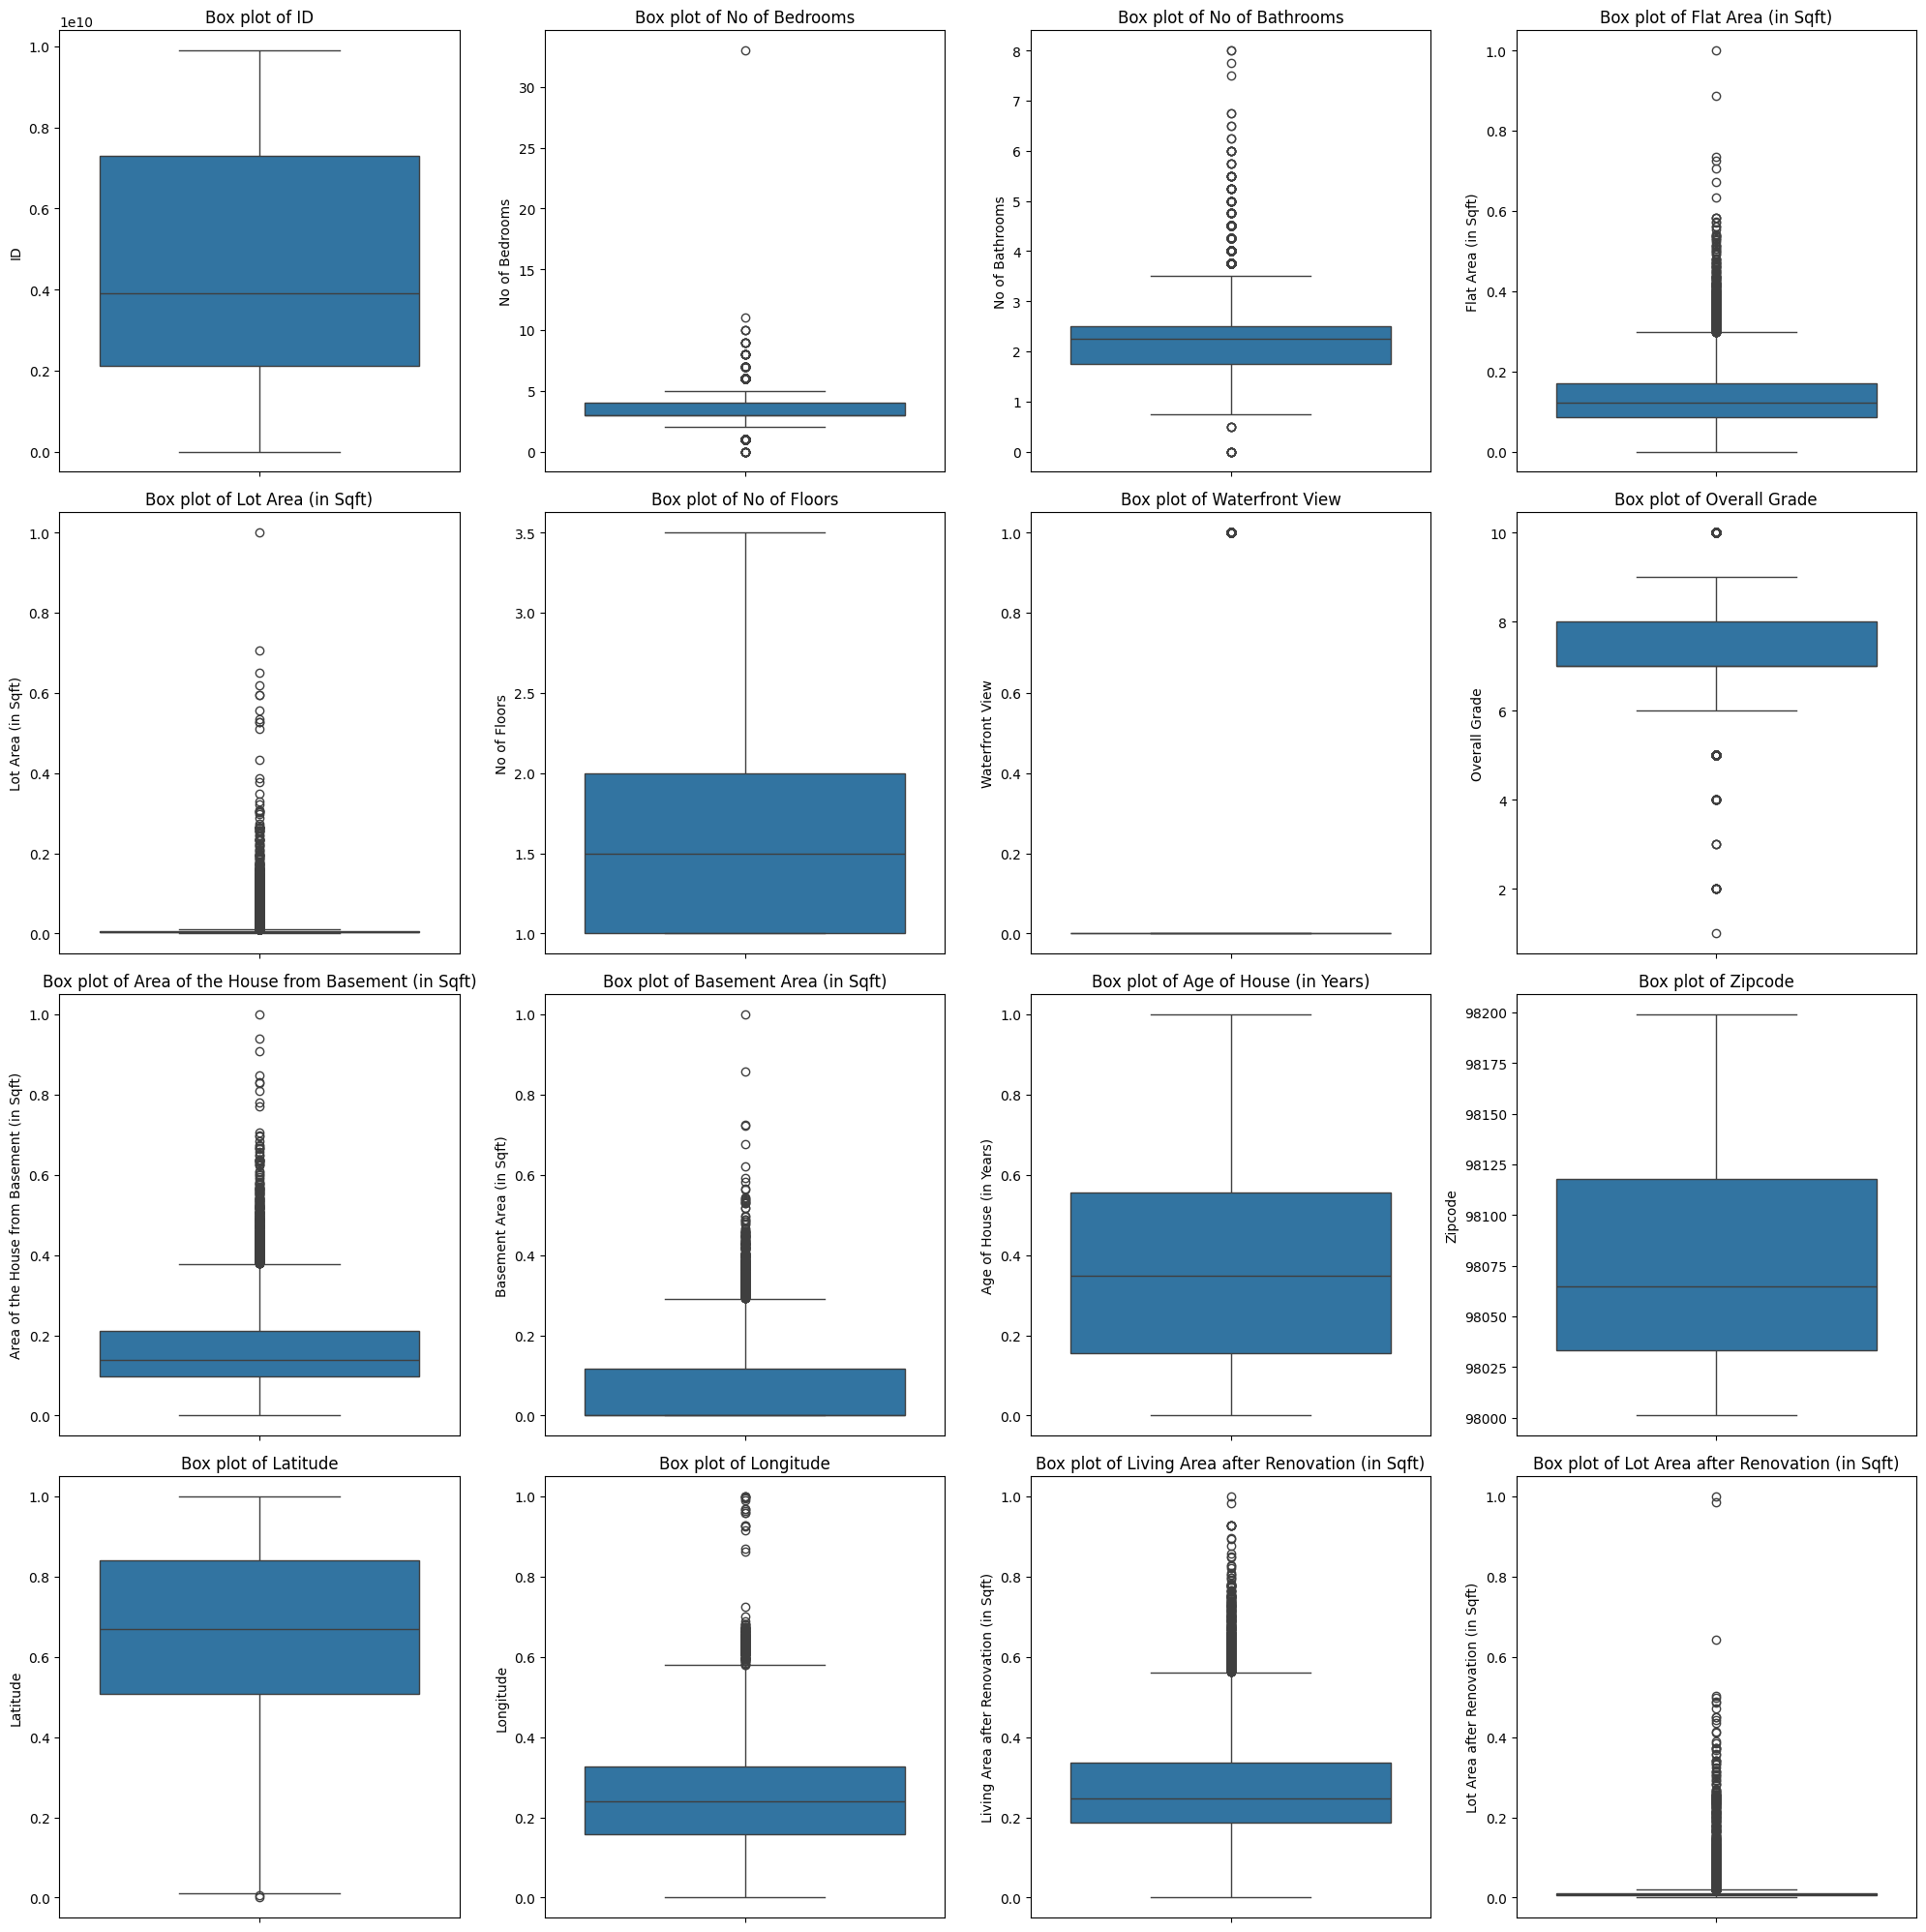

In [87]:
plt.figure(figsize=(20, 25))

for i, column in enumerate(hprice_df.columns):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(y=hprice_df[column])
    plt.title(f'Box plot of {column}')

plt.tight_layout()
plt.show()

#Outlier Handling

In [88]:
def clip_outliers(column):
    Q1 = hprice_df[column].quantile(0.25)
    Q3 = hprice_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    hprice_df[column] = np.clip(hprice_df[column], lower_bound, upper_bound)
    return hprice_df


for column in hprice_df.columns:
    hprice_df = clip_outliers(column)

hprice_df.head()

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,3.0,1.00,0.067170,0.003108,1.0,0,7.0,0.097588,0.000000,0.521739,98178.0,0.571498,0.217608,0.161934,0.005742
1,6414100192,3.0,2.25,0.172075,0.004072,2.0,0,7.0,0.206140,0.082988,0.556522,98125.0,0.908959,0.166113,0.222165,0.008027
2,5631500400,2.0,1.00,0.036226,0.005743,1.0,0,6.0,0.052632,0.000000,0.713043,98028.0,0.936143,0.237542,0.399415,0.008513
3,2487200875,4.0,3.00,0.126038,0.002714,1.0,0,7.0,0.083333,0.188797,0.434783,98136.0,0.586939,0.104651,0.165376,0.004996
4,1954400510,3.0,2.00,0.104906,0.004579,1.0,0,8.0,0.152412,0.000000,0.243478,98074.0,0.741354,0.393688,0.241094,0.007871


## Boxplot after outlier handling

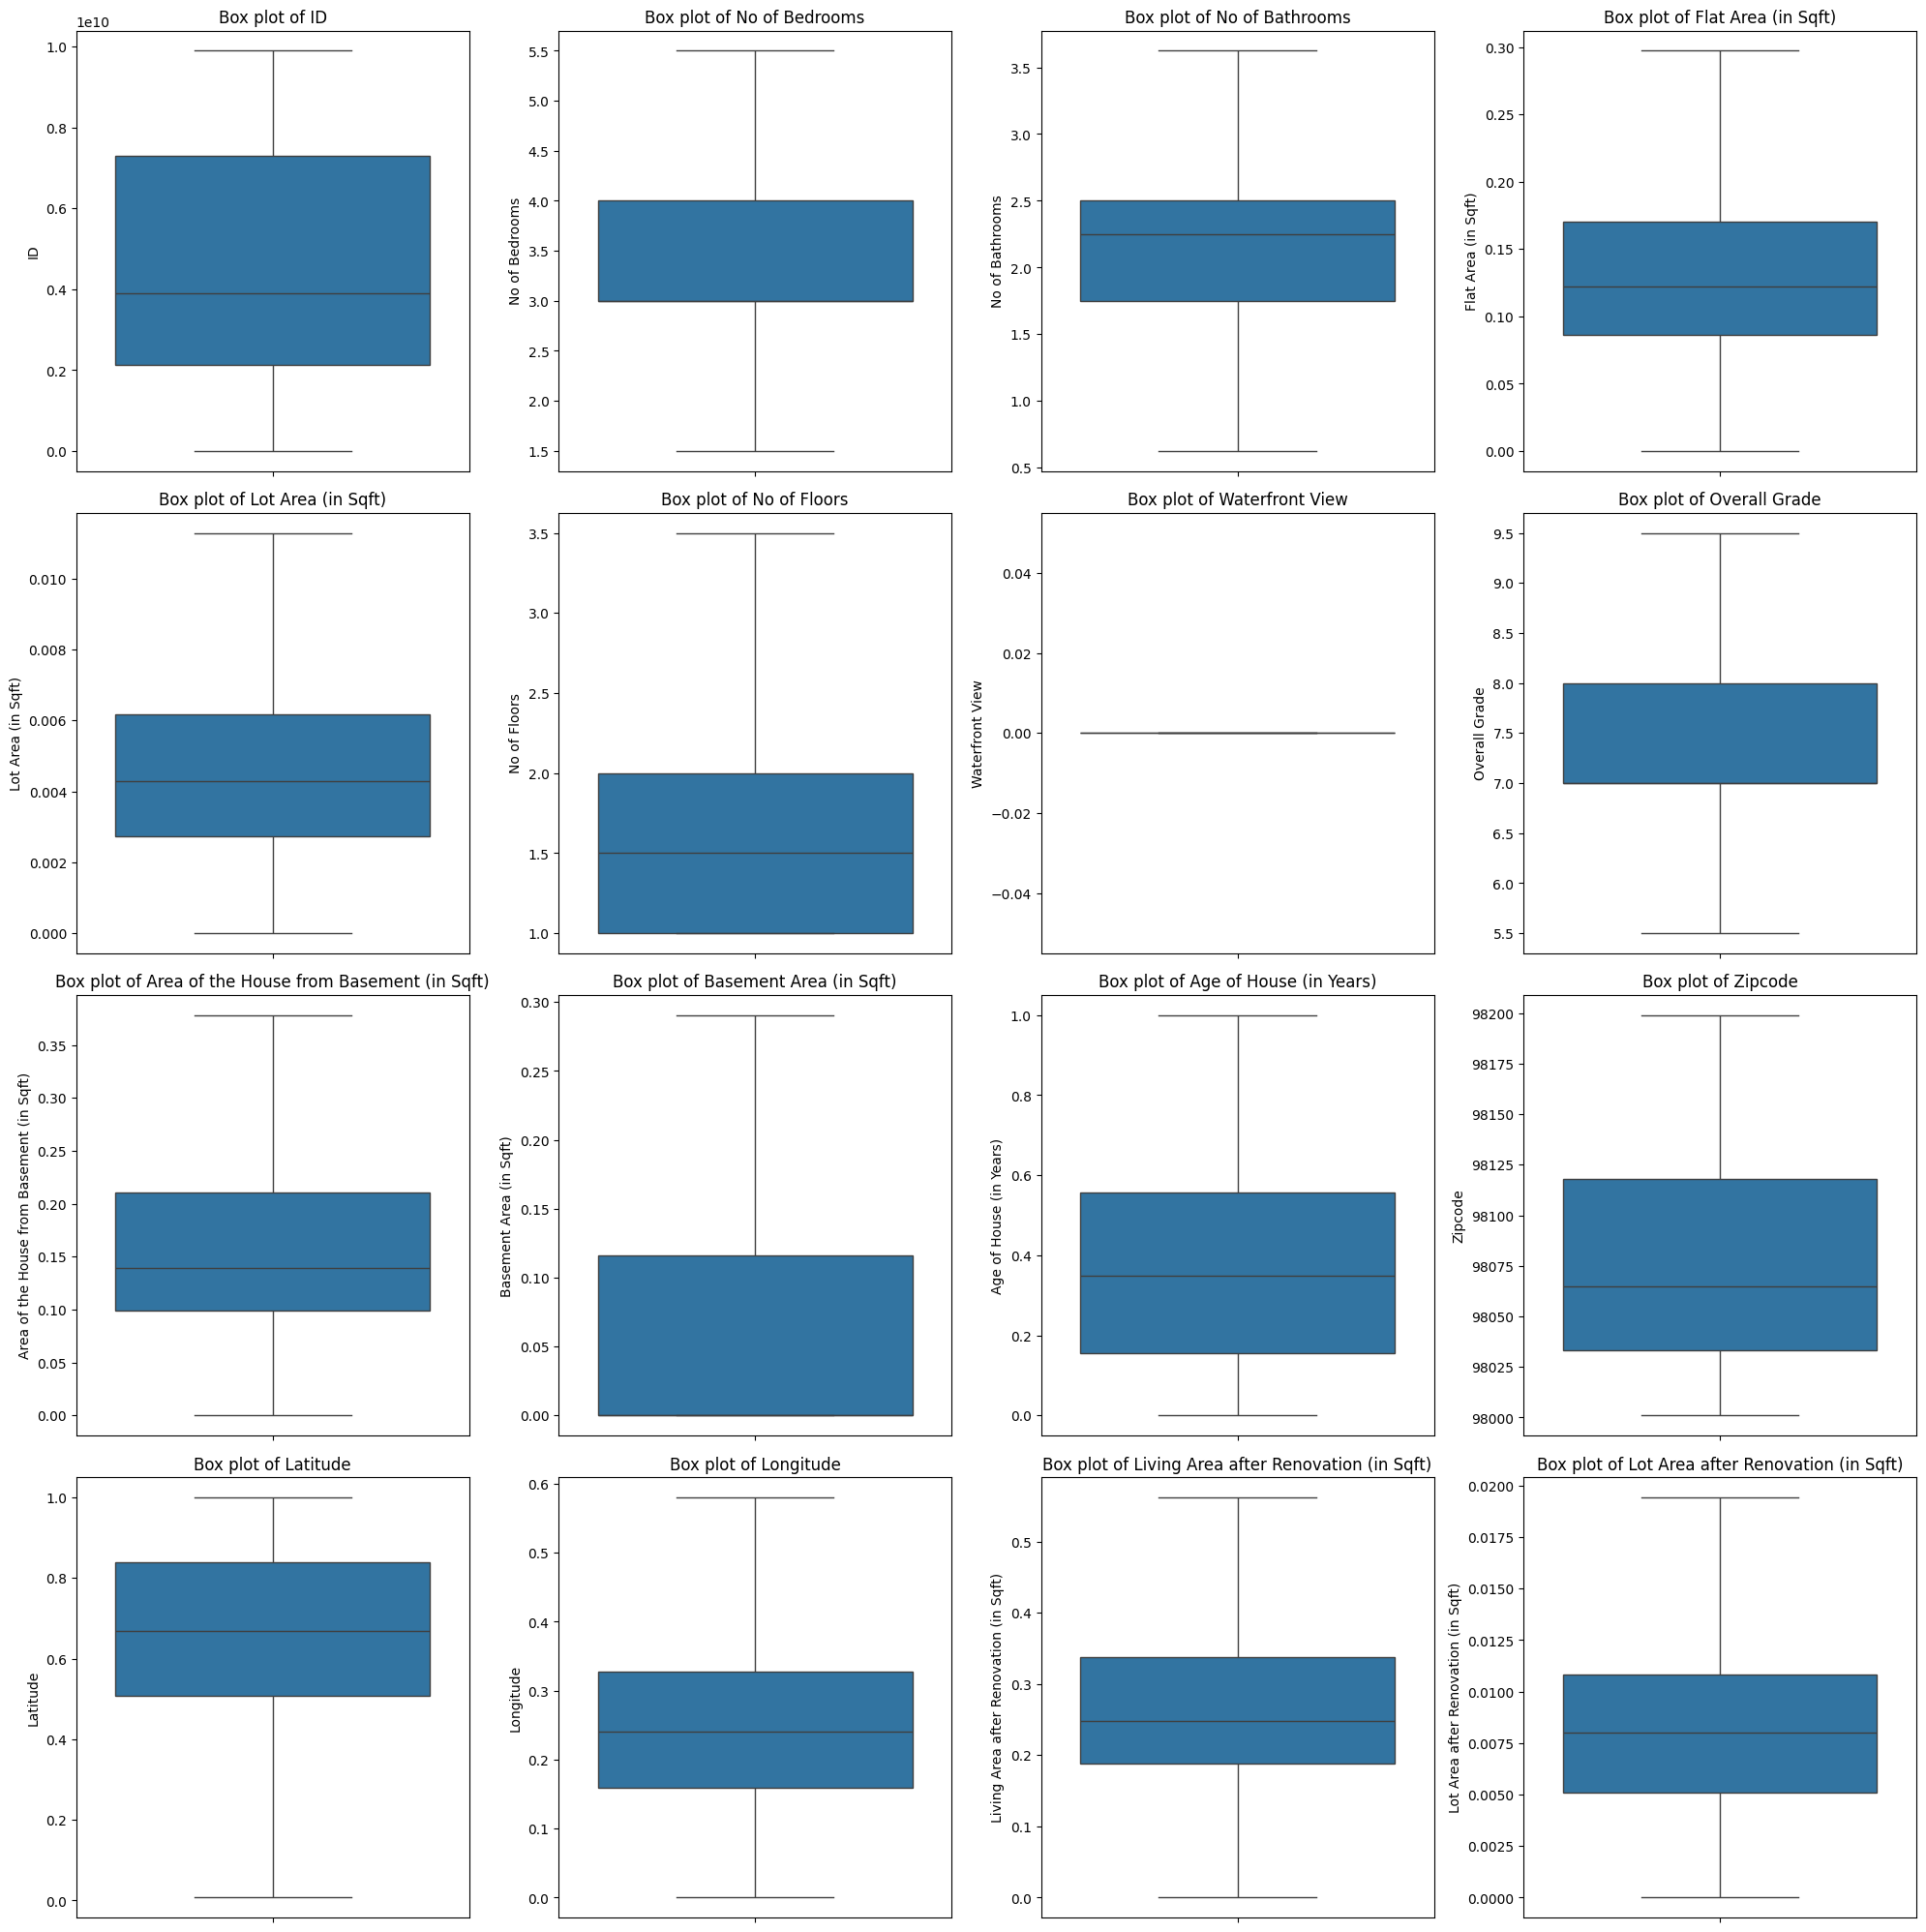

In [89]:
plt.figure(figsize=(20, 25))

for i, column in enumerate(hprice_df.columns):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(y=hprice_df[column])
    plt.title(f'Box plot of {column}')

plt.tight_layout()
plt.show()

# Train Test Split

In [90]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)   # 20 % of random data to test and remaining 80 % train

In [91]:
X_train

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
18144,9834200555,4,3.50,0.211321,0.002144,2.0,0,8,0.233553,0.139004,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12729,1926049385,4,2.50,0.178113,0.004046,2.0,0,8,0.214912,0.082988,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
14110,8887001215,3,1.75,0.118491,0.028807,1.5,0,8,0.172149,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7234,984100010,4,2.25,0.135094,0.004349,1.0,0,7,0.127193,0.130705,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10165,9560800390,3,2.25,0.128302,0.004131,2.0,0,8,0.186404,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11970,1775920340,4,1.75,0.162264,0.009819,1.0,0,7,0.120614,0.217842,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21583,2025049203,2,1.00,0.031698,0.000386,2.0,0,7,0.046053,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5396,9187200285,6,1.75,0.198491,0.002714,2.5,0,9,0.273026,0.029046,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
866,3955900830,3,2.50,0.239245,0.003677,2.0,0,7,0.347588,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [92]:
X_test

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
18171,203900610,3,1.75,0.064906,0.007728,1.0,0,7,0.094298,0.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11859,5244801275,2,1.00,0.061887,0.002073,1.0,0,6,0.049342,0.076763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
17578,7625702616,2,2.50,0.039170,0.000254,2.0,0,7,0.056908,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6413,2426049174,3,2.25,0.116981,0.006045,2.0,0,7,0.169956,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15372,5100404761,3,2.00,0.117736,0.005482,1.0,0,7,0.072368,0.186722,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11589,1118001820,4,3.25,0.166792,0.003199,1.5,0,8,0.183114,0.112033,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2528,4477000270,3,2.00,0.184151,0.009181,2.5,0,9,0.267544,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19160,4140090110,4,2.25,0.144151,0.003865,2.0,0,8,0.209430,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7093,8656800020,3,2.50,0.087547,0.006639,2.0,0,7,0.127193,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
y_train

,Sale Price
18144,760000.0
12729,559950.0
14110,407185.0
7234,300000.0
10165,445000.0
...,...
11970,484000.0
21583,399950.0
5396,823000.0
866,467000.0


In [94]:
y_test

,Sale Price
18171,339000.0
11859,410500.0
17578,219000.0
6413,481500.0
15372,547500.0
...,...
11589,1140000.0
2528,565000.0
19160,512500.0
7093,309000.0
